# Political Tweet Classification: SLP vs. MLP vs. SVM

This notebook builds and compares three text classifiers for predicting the political party (Democrat vs. Republican) of U.S. congressional tweets, using a dataset of 86,460 tweets from elected officials.

The pipeline covers text cleaning, TF-IDF vectorization, exploratory word frequency analysis, and model evaluation across three approaches:
- **Single-Layer Perceptron (SLP)** — shallow neural network baseline
- **Multi-Layer Perceptron (MLP)** — 3-layer network with 25 neurons per layer
- **LinearSVC (SVM)** — linear support vector machine with Platt scaling for probability calibration

**Key question:** Does model complexity improve political tweet classification, or does a linear SVM outperform neural network approaches on this high-dimensional TF-IDF feature space?

## Dependencies

In [ ]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import emoji

## Data Loading & Exploration

In [ ]:
# Assign dataset to variable data

data = pd.read_csv('tweetdata1.csv')

In [ ]:
# Print dimensions and first 5 lines of dataset

print(data.shape)
print(data.head)

(86460, 3)
<bound method NDFrame.head of             Party         Handle  \
0        Democrat  RepDarrenSoto   
1        Democrat  RepDarrenSoto   
2        Democrat  RepDarrenSoto   
3        Democrat  RepDarrenSoto   
4        Democrat  RepDarrenSoto   
...           ...            ...   
86455  Republican    RepTomPrice   
86456  Republican    RepTomPrice   
86457  Republican    RepTomPrice   
86458  Republican    RepTomPrice   
86459  Republican    RepTomPrice   

                                                   Tweet  
0      Today, Senate Dems vote to #SaveTheInternet. P...  
1      RT @WinterHavenSun: Winter Haven resident / Al...  
2      RT @NBCLatino: .@RepDarrenSoto noted that Hurr...  
3      RT @NALCABPolicy: Meeting with @RepDarrenSoto ...  
4      RT @Vegalteno: Hurricane season starts on June...  
...                                                  ...  
86455  Check out my op-ed on need for End Executive O...  
86456  Yesterday, Betty &amp; I had a great time lear.

The dataset contains 86,460 tweets across 3 columns: `Party` (Democrat/Republican), `Handle` (Twitter handle), and `Tweet` (raw text).

## Text Preprocessing & Feature Engineering

In [ ]:
# Checking data types of the variables and the counts of each party
print(data.dtypes)
print(data['Party'].value_counts())

Party     object
Handle    object
Tweet     object
dtype: object
Party
Republican    44392
Democrat      42068
Name: count, dtype: int64


All columns are object-typed. The dataset has ~2,300 more Republican tweets than Democrat tweets — a mild class imbalance worth keeping in mind during evaluation.

In [ ]:
# A function to clean the data. The function removes stop words, @mentions, hashtags, emojis, and whitespace.
# The function also converts to all lowercase

def clean_tweet(tweet):
    tweet = tweet.lower() # change tweet to all lowercase
    tweet = re.sub(r'\brt\b', '', tweet) # remove rt
    tweet = re.sub(r'@[A-Za-z0-9_]+', '', tweet)  # remove @mentions
    tweet = re.sub(r'#', '', tweet)              # remove hashtags
    tweet = emoji.replace_emoji(tweet, replace='') # remove emojis
    tweet = re.sub(r'&amp;', '', tweet) # remove amp
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet) # only include letters
    tweet = re.sub(r'\s+', ' ', tweet).strip() # remove whitespace

    stop_words = set(stopwords.words('english'))
    tweet = ' '.join([word for word in tweet.split() if word.lower() not in stop_words]) # remove stop words

    custom_stop_words = {'im', 'th', 'rt', 'amp'}
    tweet = ' '.join([word for word in tweet.split() if word not in custom_stop_words]) # remove custom stop words

    return tweet

The `clean_tweet` function applies the following preprocessing steps:
- Lowercase conversion
- Remove retweet markers (`RT`), `@mentions`, `#hashtags`, emojis, and HTML entities (`&amp;`)
- Strip non-alphabetic characters and extra whitespace
- Remove English stop words (NLTK) and custom stop words (`im`, `th`, `rt`, `amp`)

This produces a clean, normalized token sequence for each tweet.

In [ ]:
# Testing clean_tweet function with multiple test cases

print(clean_tweet("RT @NBCLatino: .@RepDarrenSoto noted that #Hurricane season starts soon!"))
print(clean_tweet("Love this policy! 🔥❤️ #Politics"))
print(clean_tweet("Betty &amp; I had a great time! 100% amazing..."))
print(clean_tweet("Love   this    policy  !"))
print(clean_tweet("Today I am going to the store and it is a great day"))

noted hurricane season starts soon
love policy politics
betty great time amazing
love policy
today going store great day


Test cases confirm the cleaning function handles mentions, hashtags, emojis, HTML entities, and extra whitespace correctly.

In [ ]:
# Applying clean_tweet function to our dataset and printing new first 5 lines

data['Tweet'] = data['Tweet'].apply(clean_tweet)
print(data['Tweet'].head())

0    today senate dems vote savetheinternet proud s...
1    winter resident alta vista teacher one several...
2    noted hurricane maria left approximately billi...
3    meeting thanks taking time meet ed marucci guz...
4    hurricane season starts june st puerto ricos r...
Name: Tweet, dtype: object


The cleaning function is applied across all 86,460 tweets.

### Exploratory Word Frequency Analysis

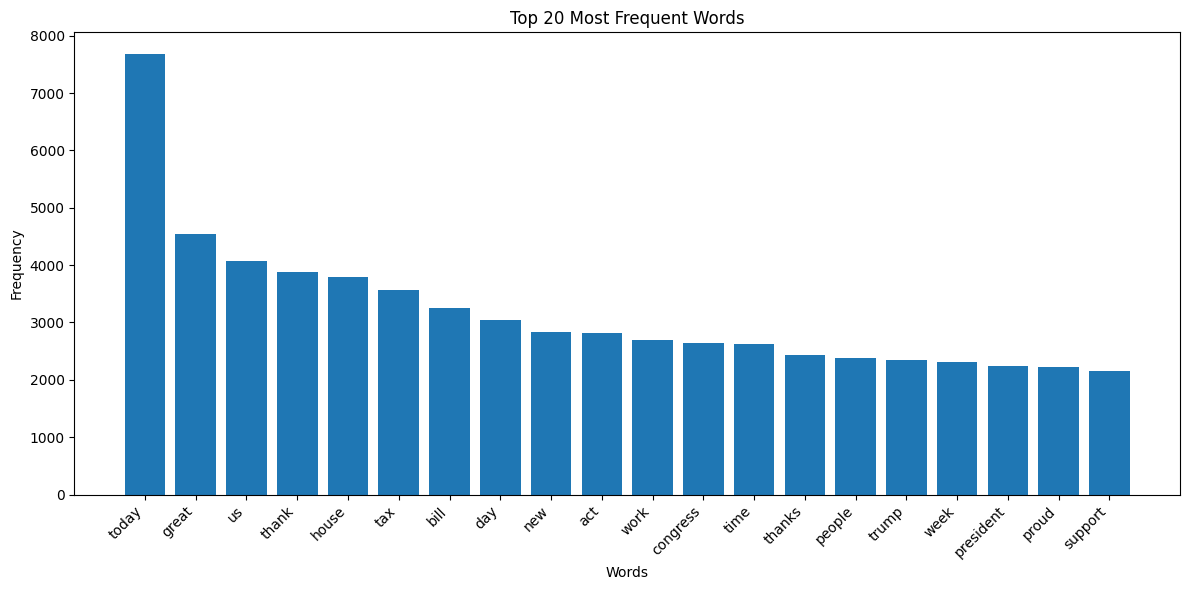

In [ ]:
# Exploratory Data Analysis - Top 20 Most Frequent Words

from collections import Counter
all_words = ' '.join(data['Tweet']).split()
word_freq = Counter(all_words)
words, counts = zip(*word_freq.most_common(20))
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

After cleaning, `today` is the most frequent word overall, followed by policy-related terms: `house`, `bill`, `act`, `congress`. The vocabulary is dominated by political and legislative language.

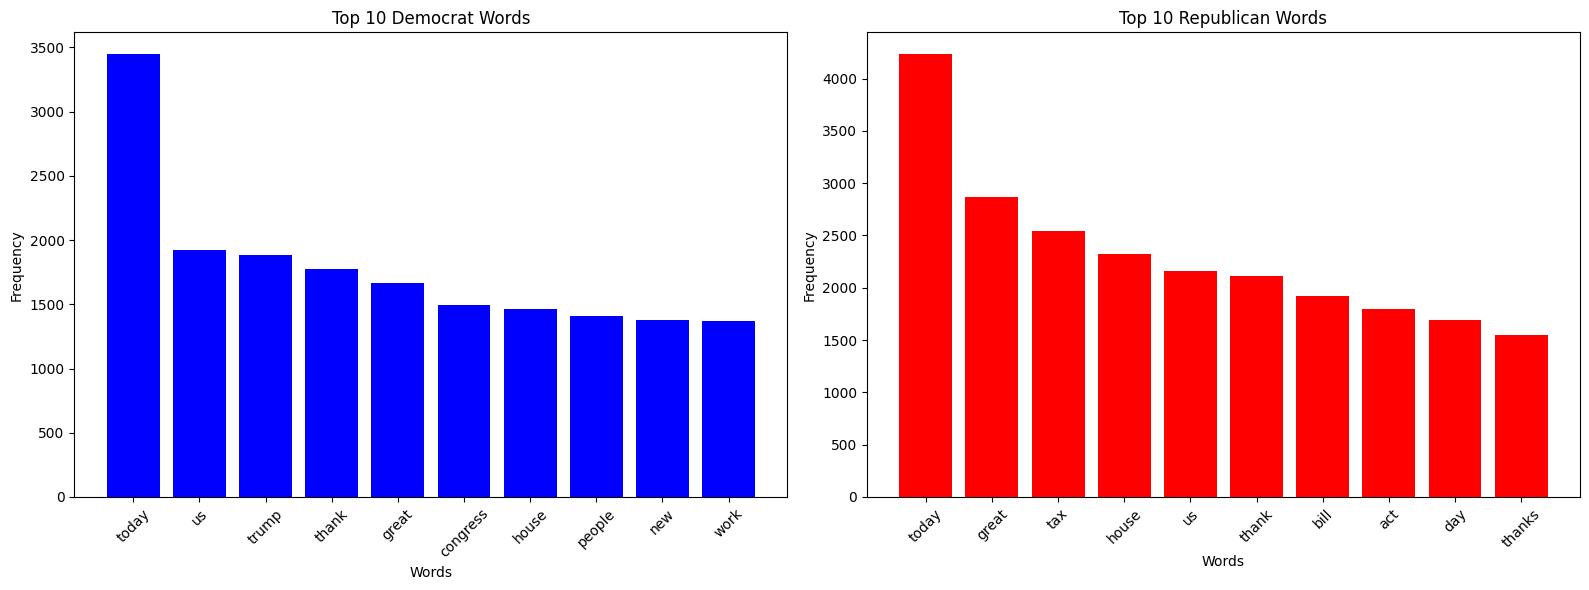

In [ ]:
# Exploratory Data Analysis - Top 10 most used words by party

dem_tweets = ' '.join(data[data['Party'] == 'Democrat']['Tweet'])
rep_tweets = ' '.join(data[data['Party'] == 'Republican']['Tweet'])

dem_freq = Counter(dem_tweets.split())
rep_freq = Counter(rep_tweets.split())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

dem_words, dem_counts = zip(*dem_freq.most_common(10))
ax1.bar(dem_words, dem_counts, color='blue')
ax1.set_title('Top 10 Democrat Words')
ax1.set_xlabel('Words')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=45)

rep_words, rep_counts = zip(*rep_freq.most_common(10))
ax2.bar(rep_words, rep_counts, color='red')
ax2.set_title('Top 10 Republican Words')
ax2.set_xlabel('Words')
ax2.set_ylabel('Frequency')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Splitting by party reveals an interesting asymmetry: **`trump` appears in the top 10 Democrat words but not Republican words**, despite Trump being a Republican. Democrat tweets tend to be more people-centered (`us`, `trump`, `congress`, `people`), while Republican tweets lean more policy-centered (`tax`, `house`, `bill`, `act`). This distinction likely contributes meaningful signal to the classifiers.

### TF-IDF Vectorization & Train/Test Split

In [ ]:
# Splitting data and vectorizing data using TF-IDF

X_train, X_test, y_train, y_test = train_test_split(data['Tweet'], data['Party'], test_size=0.33, random_state=42)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(57928, 82281)


The dataset is split 67/33 into training and test sets. TF-IDF vectorization is fitted on training data only and applied to both sets, converting each tweet into a sparse vector of term frequency-inverse document frequency scores.

## Single-Layer Perceptron (SLP)

In [ ]:
# Perceptron model

from sklearn.neural_network import MLPClassifier

perceptron = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=225)
perceptron.fit(X_train_tfidf, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=225)

A single hidden layer with 10 neurons — the simplest neural network baseline.

In [ ]:
# Testing trained SLP on sample tweet 'good meeting with president Biden'

test_tweet = clean_tweet("good meeting with president Biden")
test_tfidf = tfidf.transform([test_tweet])
print(perceptron.predict(test_tfidf))

['Democrat']


Sample prediction: *"good meeting with president Biden"* → **Democrat** ✓ (intuitively correct)

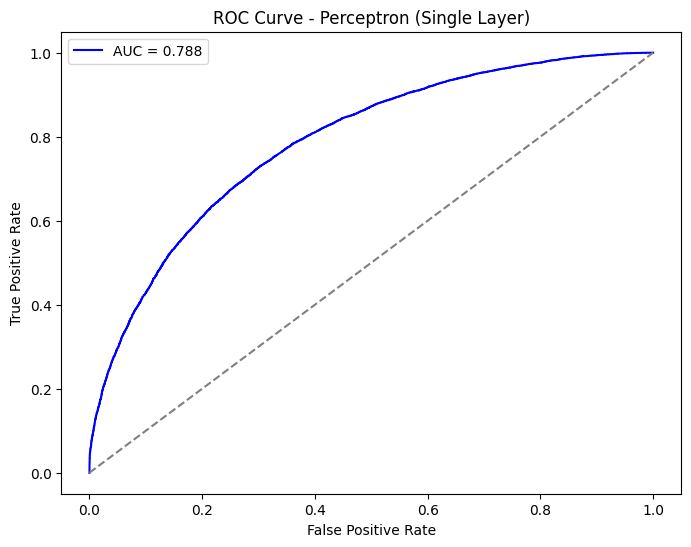

C-index (AUC): 0.788


In [ ]:
# ROC Curve for SLP model

from sklearn.metrics import roc_curve, roc_auc_score

y_scores = perceptron.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Republican')
auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title('ROC Curve - Perceptron (Single Layer)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(f'C-index (AUC): {auc:.3f}')

**AUC = 0.788** — the SLP correctly ranks Democrat vs. Republican tweets 78.8% of the time.

## Multi-Layer Perceptron (MLP)

In [ ]:
# Multi-layer Perceptron Model with 3 layers, 25 neurons per layer

mlp = MLPClassifier(hidden_layer_sizes=(25, 25, 25), max_iter=1000, random_state=225)
mlp.fit(X_train_tfidf, y_train)

MLPClassifier(hidden_layer_sizes=(25, 25, 25), max_iter=1000, random_state=225)

Three hidden layers with 25 neurons each — adds depth to test whether more capacity improves classification.

In [ ]:
# Testing trained MLP on sample tweet 'good meeting with president Biden'

test_tweet = clean_tweet("good meeting with president Biden")
test_tfidf = tfidf.transform([test_tweet])
print(mlp.predict(test_tfidf))

['Democrat']


Sample prediction: *"good meeting with president Biden"* → **Democrat** ✓

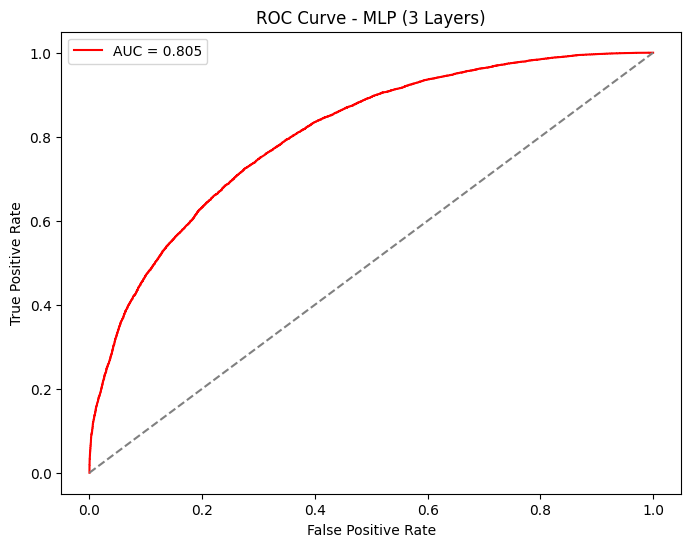

C-index (AUC): 0.805


In [ ]:
# ROC Curve for MLP model

y_scores_mlp = mlp.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_mlp, pos_label='Republican')
auc_mlp = roc_auc_score(y_test, y_scores_mlp)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='red', label=f'AUC = {auc_mlp:.3f}')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title('ROC Curve - MLP (3 Layers)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(f'C-index (AUC): {auc_mlp:.3f}')

**AUC = 0.805** — a modest improvement over the SLP (+1.7 points), suggesting additional depth helps but with diminishing returns.

## Support Vector Machine (LinearSVC)

In [ ]:
# Support Vector Machine Model

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(random_state=225)
svm_calibrated = CalibratedClassifierCV(svm)
svm_calibrated.fit(X_train_tfidf, y_train)

CalibratedClassifierCV(estimator=LinearSVC(random_state=225))

LinearSVC with Platt scaling (CalibratedClassifierCV) for probability estimates needed for ROC curve computation. Linear SVMs are particularly well-suited to high-dimensional sparse text features like TF-IDF.

In [ ]:
# Testing trained SVM on sample tweet 'good meeting with president Biden'

test_tweet = clean_tweet("good meeting with president Biden")
test_tfidf = tfidf.transform([test_tweet])
print(svm_calibrated.predict(test_tfidf))

['Democrat']


Sample prediction: *"good meeting with president Biden"* → **Democrat** ✓

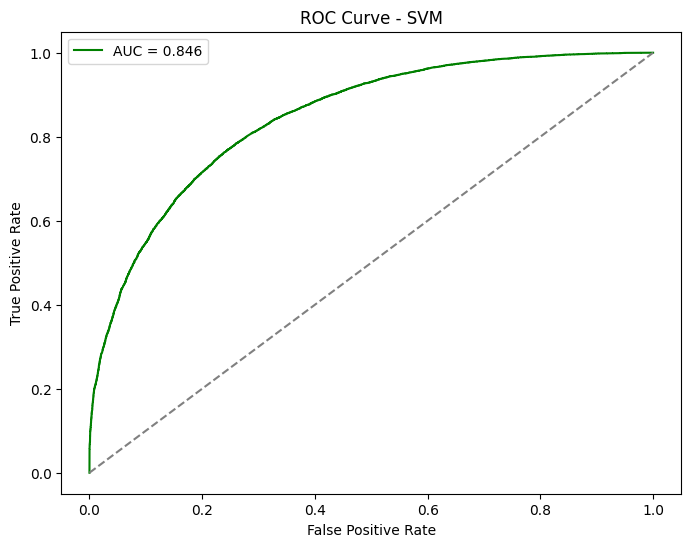

C-index (AUC): 0.846


In [ ]:
# ROC Curve for SVM model

y_scores_svm = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]
fpr_svm, tpr_svm, thresholds = roc_curve(y_test, y_scores_svm, pos_label='Republican')
auc_svm = roc_auc_score(y_test, y_scores_svm)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, color='green', label=f'AUC = {auc_svm:.3f}')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title('ROC Curve - SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(f'C-index (AUC): {auc_svm:.3f}')

**AUC = 0.846** — the strongest model by a clear margin, outperforming both perceptron variants.

## Model Comparison

| Model | AUC (C-index) |
|-------|--------------|
| Perceptron (Single Layer, 10 Neurons) | 0.788 |
| MLP (3 Layers, 25 Neurons each) | 0.805 |
| SVM | 0.846 |

The LinearSVC achieves the highest AUC (0.846), outperforming both perceptron models. This is consistent with the known strength of linear SVMs on high-dimensional sparse text data — TF-IDF vectors tend to be linearly separable, making the additional complexity of neural networks less beneficial.

## Real-World Applications

Political tweet classifiers have practical applications beyond academic analysis:

- **Voter sentiment analysis** — real-time classification of public tweets during an active campaign can surface partisan sentiment trends before poll results are available
- **Ad targeting** — political campaigns could use predicted party affiliation to serve targeted messaging to likely supporters
- **Media monitoring** — automatically categorizing political discourse at scale enables tracking of messaging patterns across parties over time

These applications come with important ethical considerations around privacy, consent, and the potential for misuse in political manipulation.

## Conclusions

This project compared three classifiers for political party prediction from tweet text using TF-IDF features.

| Model | AUC |
|---|---|
| **LinearSVC (SVM)** | **0.846** |
| MLP (3 layers, 25 neurons) | 0.805 |
| SLP (1 layer, 10 neurons) | 0.788 |

**Key takeaways:**
- **LinearSVC outperformed both neural network approaches** — consistent with the general pattern that linear models excel on high-dimensional sparse TF-IDF representations where the feature space is already well-structured.
- **Increasing perceptron depth helped marginally** (SLP → MLP: +1.7 AUC points), but neither neural network closed the gap with the SVM.
- **Word frequency analysis revealed a genuine partisan signal** — Democrat tweets reference `trump` prominently while Republican tweets focus on policy terms, giving models a meaningful vocabulary distinction to exploit.
- The ~2,300 tweet class imbalance (more Republican tweets) may slightly bias all models toward Republican predictions.

**Potential next steps:** Experimenting with transformer-based embeddings (e.g., BERT, RoBERTa) which capture semantic context beyond bag-of-words, applying SMOTE or class weighting to address the class imbalance, or extending to multi-class classification across individual politicians.